/var/folders/b6/zj_lgsyj5f3fyp934xb5ck_00000gn/T/ipykernel_83068/2612580981.py:71: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(point[0], point[1], point[2], alpha=0.6, c='blue', cmap='viridis')


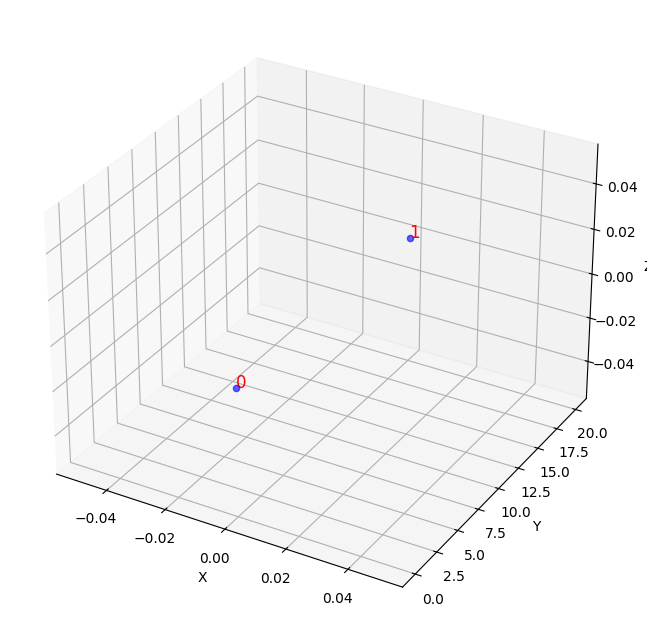

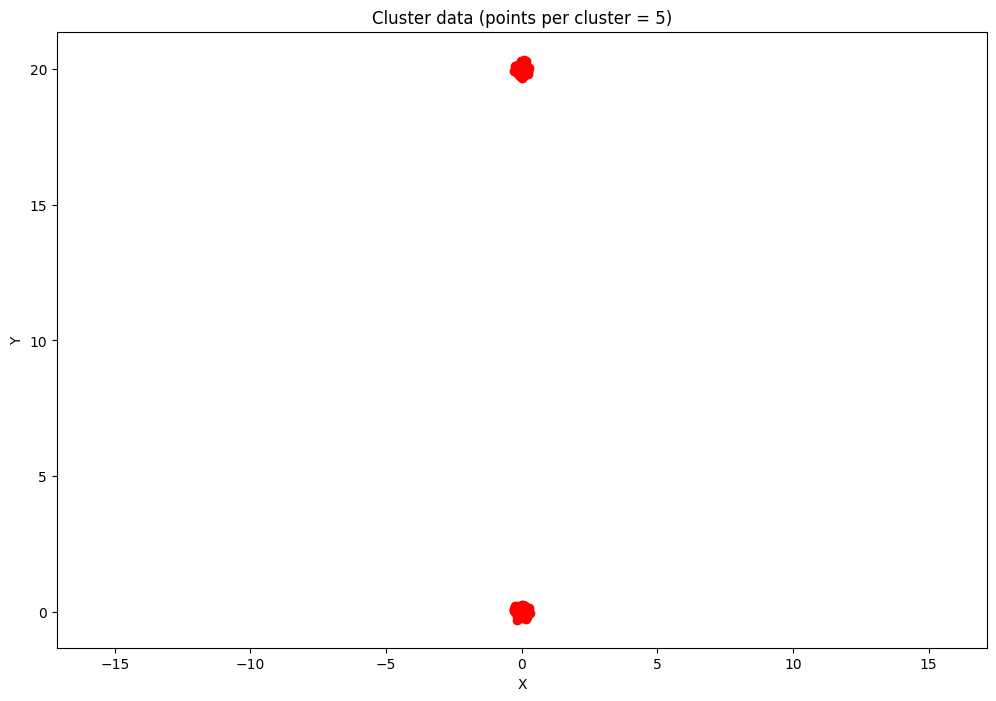

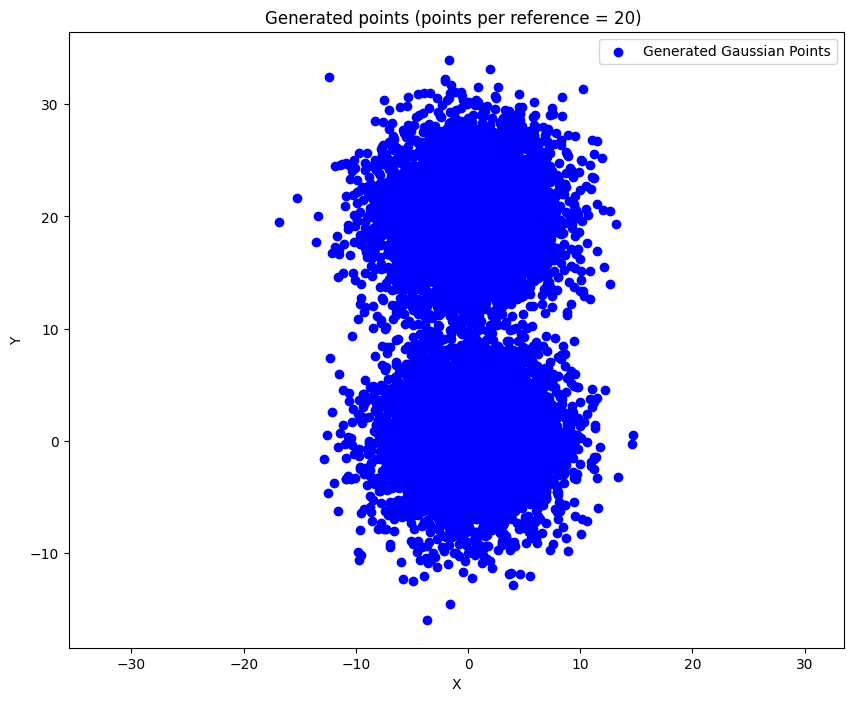

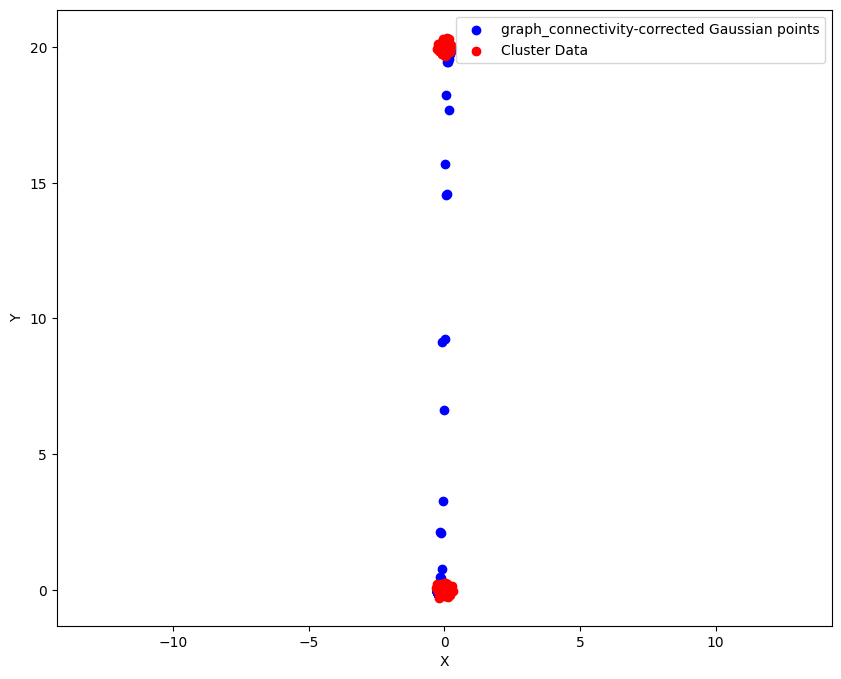

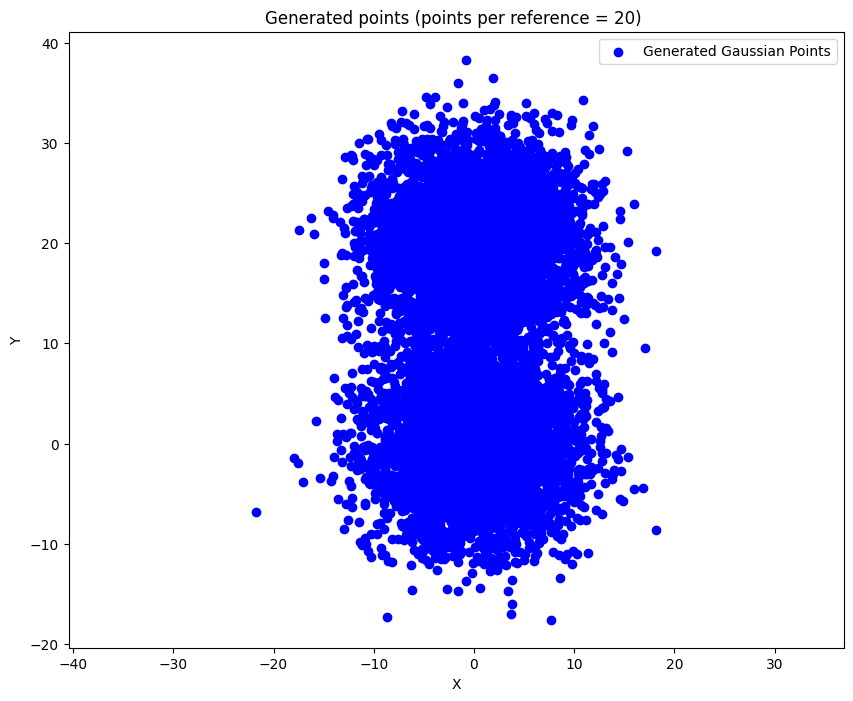

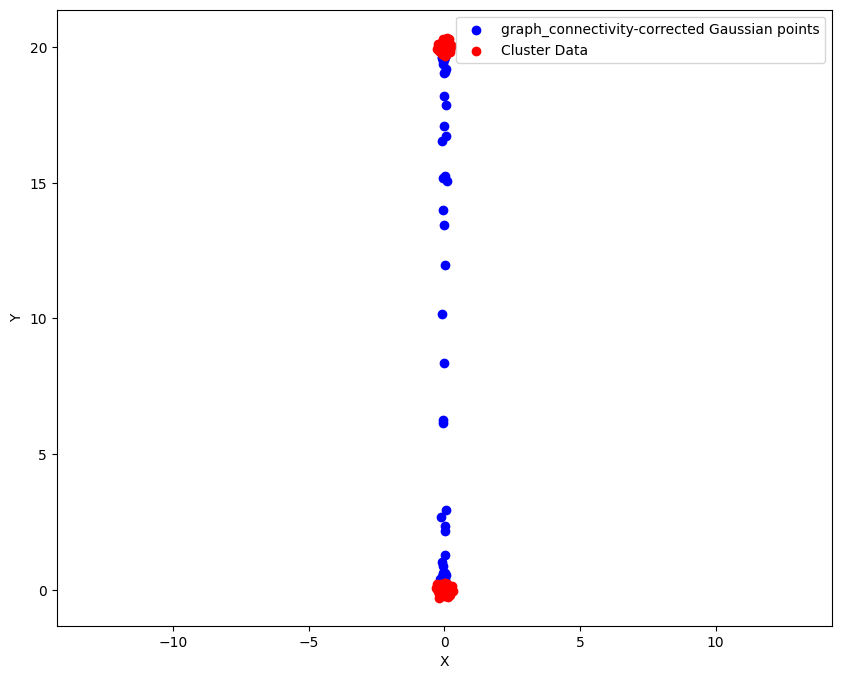

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pandas.io.sas.sas_constants import dataset_length
from sklearn.cluster import KMeans
from sklearn.datasets import make_swiss_roll
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA

def build_affinity_matrix(O,N,sigma=1.0):
    dist_NO = pairwise_distances(N,O, squared= True)
    dist_ON = dist_NO.T

    K_NO = np.exp(-dist_NO/(2*sigma**2))
    K_ON = np.exp(-dist_ON/(2*sigma**2))
    K_NN = K_NO @ K_ON
    return K_NN


def sort_swiss(data, label):
    distances = np.linalg.norm(data, axis=1)
    sorted_idx = np.argsort(distances)
    return data[sorted_idx], label[sorted_idx]

def reference_selection(data, n_clusters, random_state):
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    kmeans.fit(data)
    return kmeans.cluster_centers_

def generate_gaussian(data, num_gauss_points, std=0.5):
    gaussian_points = []
    for point in data:
        points = np.random.normal(loc=point, scale = std, size =(num_gauss_points, len(point)))
        gaussian_points.append(points)
    return np.vstack(gaussian_points)


def graph_connectivity(O,N,K_NN,t):
    D = np.diag(np.sum(K_NN, axis=1))
    P_NN = np.linalg.inv(D) @ K_NN
    P_NN_powered = np.linalg.matrix_power(P_NN, t)
    N_graph_connectivity = P_NN_powered @ N
    all_points = np.vstack([O, N_graph_connectivity])
    return N_graph_connectivity, all_points

num_data_points = 100
noise = 0.2

std_list = [4.0, 5.0] 
num_points_list = [20] #[50, 100, 200, 500, 1000]
t_list=[1]
n_points = 5
nx, ny, nz = (1, 2, 0)


x = np.linspace(0, 1, nx)
y = np.linspace(0, 20, ny)
z = np.linspace(0, 0)

xv, yv, zv = np.meshgrid(x, y, z)

xyz_matrix = np.column_stack((xv.flatten(), yv.flatten(), zv.flatten()))
xyz_matrix_unique = np.unique(xyz_matrix, axis=0)


fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
for i, point in enumerate(xyz_matrix_unique):
    ax.scatter(point[0], point[1], point[2], alpha=0.6, c='blue', cmap='viridis')
    ax.text(point[0], point[1], point[2], f'{i}', color='red', fontsize=12)  # Add point numbers
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()


original_data = generate_gaussian(xyz_matrix,5,0.1)

fig = plt.figure(figsize=(12, 8))
plt.scatter(original_data[:,0],original_data[:,1], c='red')
plt.title(f'Cluster data (points per cluster = {n_points})')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.show()


reference_points = original_data

for std in std_list:   
    for num_gauss_points in num_points_list:
        generated_points = generate_gaussian(reference_points,num_gauss_points,std)

        fig = plt.figure(figsize=(10,8))
        plt.scatter(generated_points[:,0], generated_points[:,1],label='Generated Gaussian Points', c= 'blue')
        plt.title(f'Generated points (points per reference = {num_gauss_points}) ')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.axis('equal')
        plt.legend()
        plt.show()

        affinity_matrix_NN = build_affinity_matrix(O=original_data,N=generated_points,sigma = 1.0)
        

        for t in t_list:
            N_graph_connectivity, all_points = graph_connectivity(original_data,generated_points, affinity_matrix_NN, t)

            plt.figure(figsize=(10,8))
            plt.scatter(N_graph_connectivity[:,0], N_graph_connectivity[:,1], label = 'graph_connectivity-corrected Gaussian points', c = 'blue')
            plt.scatter(original_data[:,0], original_data[:,1],label ='Cluster Data', c='red')
            plt.xlabel('X')
            plt.ylabel('Y')
            plt.axis('equal')
            plt.legend()
            plt.show()